<h1>Why AutoGRAD</h1>
While working with neural networks we encounter with nested function and their derivatives<br>
And for weight updation we find derivative of those nested function which is a hectic task<br>
AutoGRAD helps us with this

In [1]:
def dy_dx(x): # This function returns derivative of y = x^2
    return 2*x

dy_dx(3)

6

<h3>Using AutoGRAD</h3>

In [2]:
import torch

In [3]:
x = torch.tensor(3.0, requires_grad=True)
y = x**2

In [4]:
# When we create a tensor with require_grad = True 
# It make a computational graph at the backend which 
# remembers the relation backward also
x

tensor(3., requires_grad=True)

In [5]:
y

tensor(9., grad_fn=<PowBackward0>)

In [6]:
# To compute gradient we use backward()
# so from y to back to last all gradients are calculated
y.backward()
x.grad

tensor(6.)

<h3>AutoGrad on nested function</h3>

In [7]:
x = torch.tensor(3.0, requires_grad= True)

In [8]:
y = x**2

In [9]:
z = torch.sin(y)

In [10]:
x

tensor(3., requires_grad=True)

In [11]:
y

tensor(9., grad_fn=<PowBackward0>)

In [12]:
z

tensor(0.4121, grad_fn=<SinBackward0>)

In [13]:
# x --- sqr --- y --- sin --- z 
# This is how the computation graph looks

z.backward()
x.grad

tensor(-5.4668)

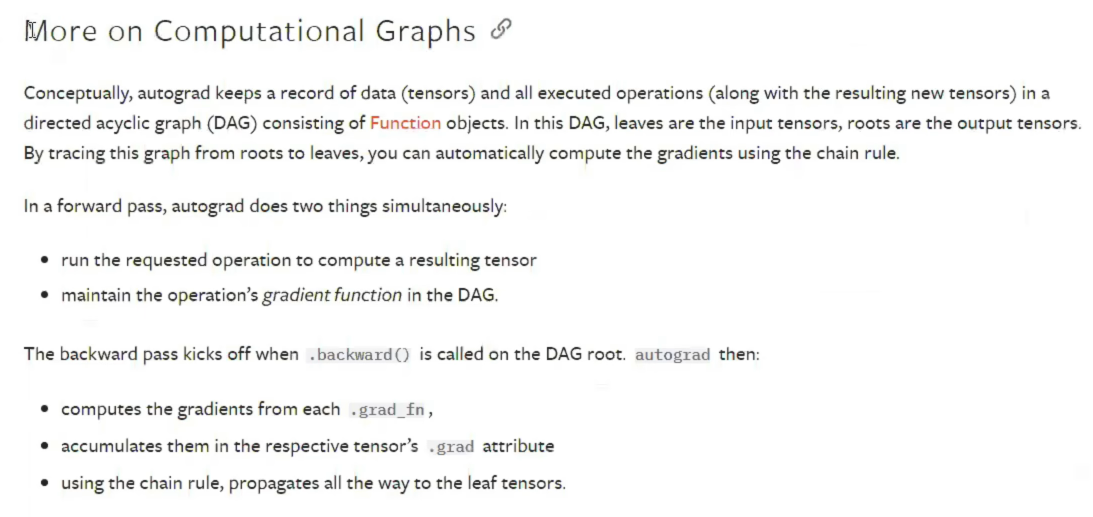

In [14]:
# So this will not work
y.grad

/tmp/ipykernel_2316/364888527.py:2: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /__w/pytorch/pytorch/build/aten/src/ATen/core/TensorBody.h:488.)
  y.grad


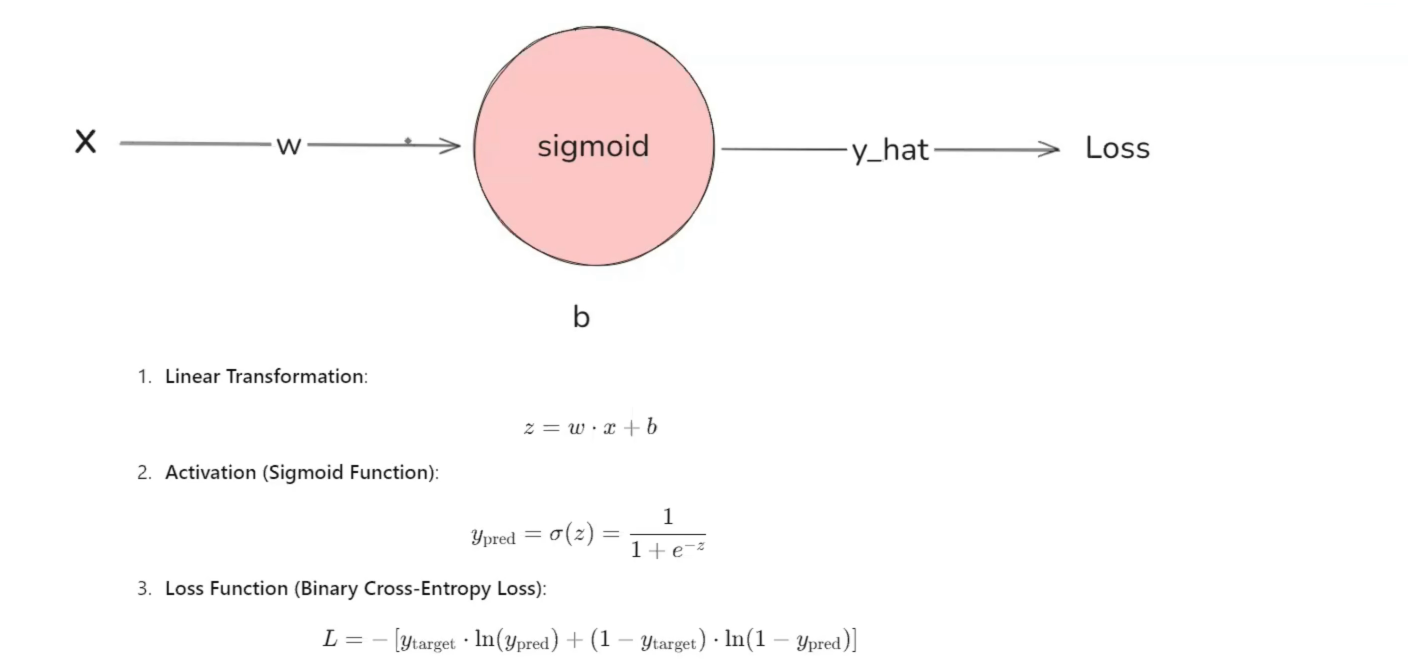

Here we want to calculate the derivative of Loss wih respect to w and b

<h3>If we do it manually</h3>

In [15]:
y = torch.tensor(0.0)   # True label

w = torch.tensor(1.0)   # Weights
b = torch.tensor(0.0)   # bias

In [16]:
# Binary Cross entropy Loss
def binary_cross_entropy_loss(prediction, target):
    epsilon = 1e-8
    prediction = torch.clamp(prediction, epsilon, 1-epsilon)
    return -(target * torch.log(prediction) + (1 - target)* torch.log(1 - prediction))

In [17]:
# Forward Pass
z = w * x + b 
y_pred = torch.sigmoid(z)

# Computer binary crosss etropy loss
loss = binary_cross_entropy_loss(y_pred, y)

In [18]:
loss

tensor(3.0486, grad_fn=<NegBackward0>)

In [19]:
# Derivatives
# 1. Derivative of Loss with respect to prediction
dloss_dy_pred = (y_pred - y)/(y_pred * (1-y_pred))

# 2. Derivative of Prediction with respect to z
dy_pred_dz = y_pred * (1 - y_pred)

# 3. Derivaive of z with respect to w and b
dz_dw = x
dz_db = 1

dL_dw = dloss_dy_pred * dy_pred_dz * dz_dw
dL_db = dloss_dy_pred * dy_pred_dz * dz_db

In [20]:
print(f"Manual gradient of loss w.r.t weight : {dL_dw}")
print(f"Manual gradient of loss w.r.t bias : {dL_db}")

Manual gradient of loss w.r.t weight : 2.857722282409668
Manual gradient of loss w.r.t bias : 0.9525741338729858


<h3>Using autograd

In [21]:
x = torch.tensor(6.7)
y = torch.tensor(0.0)

w = torch.tensor(1.0, requires_grad = True)
b = torch.tensor(0.0, requires_grad = True)

In [22]:
w

tensor(1., requires_grad=True)

In [23]:
b

tensor(0., requires_grad=True)

In [ ]:
z = w*x + b

In [25]:
z

tensor(6.7000, grad_fn=<AddBackward0>)

In [26]:
y_pred = torch.sigmoid(z)
y_pred

tensor(0.9988, grad_fn=<SigmoidBackward0>)

In [27]:
loss = binary_cross_entropy_loss(y_pred, y)
loss

tensor(6.7012, grad_fn=<NegBackward0>)

In [28]:
loss.backward()
print(w.grad)
print(b.grad)

tensor(6.6918)
tensor(0.9988)


<h3>With vector inputs</h3>

In [29]:
x = torch.tensor([1.0, 2.0, 3.0], requires_grad = True)
x

tensor([1., 2., 3.], requires_grad=True)

In [30]:
y = (x**2).mean()
y

tensor(4.6667, grad_fn=<MeanBackward0>)

In [31]:
y.backward()
x.grad

tensor([0.6667, 1.3333, 2.0000])

<h3>Clearning Gradients</h3>
when we run backward() more than 1 time it doenst waork

In [ ]:
x = torch.tensor(2.0, requires_grad= True)


In [58]:
# Running the forward pass for the first time
y = x**2

In [59]:
y.backward()
x.grad

tensor(4.)

In [50]:
# Run the forward passs again
y = x**2

In [51]:
y.backward()
x.grad
# This gives a different gradient since the previous gradient was not cleared

tensor(8.)

In [52]:
# Clear the gradient
x.grad.zero_()
y = x**2
y.backward()
x.grad

tensor(4.)

<h3>Disabling Gradient Tracking</h3>
You need gradient during training to update weights<br>
But during Testing you dont need it so you have to disable it

In [54]:
# Option 1 - require_grad_(False)
# Option 2 - detach()
# Option 3 - torch.no_grad()

In [56]:
x.requires_grad_(False)
print(x)
y = x**2
print(y)

tensor(2.)
tensor(4.)


In [60]:
z = x.detach()
print(z)

y = x**2 # Using the x which keeps gradient
print(y) 

y1 = z**2 # Using the z which doent keep gradient
print(y1)

# We can call y.backward() but cannot call y1.backward()


tensor(2.)
tensor(4., grad_fn=<PowBackward0>)
tensor(4.)


In [62]:
# Let x be something having gradient but I want y without gradient
x = torch.tensor(2.0, requires_grad= True)
print(x)

with torch.no_grad():
    y = x**2

tensor(2., requires_grad=True)


In [63]:
y

tensor(4.)